# Spam Text Classification

## Student Details

- Student 1: Isabel D., ID: 7277
- Student 2: Noam R., ID: 1121


## Project Introduction

In this notebook we solved an NLP text classification problem: classifying SMS messages as **spam** or **ham**. The input is the raw message text, and the output is a predicted class label. We implemented a **Multinomial Naive Bayes model from scratch** and used text preprocessing and vectorization to convert text messages into numeric features. The main evaluation metric is **macro F1**, because both spam and ham are important classes in this task.


## Dataset Source

- **Dataset name:** SMS Spam Collection Dataset
- **Source:** Kaggle
- **URL:** https://www.kaggle.com/datasets/team-ai/spam-text-message-classification
- **Description:** The dataset contains SMS text messages labeled as either spam or ham. Our learning problem is supervised binary text classification: given a message, predict whether it is spam or ham.


## AI / Chatbot Usage and Prompts

We used AI as a learning and consultation tool. The main purpose was to better understand theoretical and methodological concepts such as suitable algorithms for text classification, Multinomial Naive Bayes, Laplace smoothing, the alpha parameter, zero probabilities, log probabilities, feature-engineering methods, and evaluation metrics such as accuracy, F1, and macro F1.

AI was not used as a substitute for understanding the material. The implementation, testing, explanations, and final decisions were written, checked, and verified by us.

**Prompt 1:**
Which machine learning algorithms are suitable for SMS spam classification when the input is text and the output is spam or ham?

**Purpose:**
To compare possible supervised classification algorithms and understand why Multinomial Naive Bayes is a reasonable choice for this task.

**Prompt 2:**
Compare KNN, Logistic Regression, Decision Trees, and Multinomial Naive Bayes for text classification. Which one is simpler to implement from scratch and explain clearly?

**Purpose:**
To understand the advantages and disadvantages of different algorithms before choosing one.

**Prompt 3:**
Explain how Multinomial Naive Bayes works for text classification in simple terms.

**Purpose:**
To understand why this algorithm is suitable for SMS spam classification.

**Prompt 4:**
How does Laplace smoothing prevent zero probabilities when a word did not appear in the training examples of a certain class?

**Purpose:**
To understand why smoothing is necessary before implementing the likelihood calculation.

**Prompt 5:**
When should we use F1 for one class, macro F1, or accuracy in a classification problem?

**Purpose:**
To understand which metric best fits our project and assignment explanation.

**Prompt 6:**
What is the difference between fitting a vectorizer on training data and transforming test data?

**Purpose:**
To understand why the test set must remain unseen during training and feature engineering.


In [1]:
import re
from collections import Counter
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)

In [2]:
data_path = Path("SPAM text message 20170820 - Data.csv")
if not data_path.exists():
    data_path = Path("spam_mails") / "SPAM text message 20170820 - Data.csv"

if not data_path.exists():
    raise FileNotFoundError(
        f"Could not find the dataset file at {data_path}."
    )

raw_df = pd.read_csv(data_path)
raw_df.columns = raw_df.columns.str.strip()
if set(["v1", "v2"]).issubset(raw_df.columns):
    raw_df = raw_df.rename(columns={"v1": "Category", "v2": "Message"})

if not set(["Category", "Message"]).issubset(raw_df.columns):
    raise ValueError("Expected columns 'Category' and 'Message' in the dataset.")

# Keep the original dataset as df for the entire project.
df = raw_df.copy()

print("Original dataset columns:", list(df.columns))
print("Original dataset shape:", df.shape)
display(df.head())

Original dataset columns: ['Category', 'Message']
Original dataset shape: (5572, 2)


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Manual metrics used for cross-validation and final evaluation.

In [3]:
def accuracy_score_manual(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))


def precision_score_manual(y_true, y_pred, positive_label="spam"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = np.sum((y_true == positive_label) & (y_pred == positive_label))
    fp = np.sum((y_true != positive_label) & (y_pred == positive_label))
    denominator = tp + fp
    return float(tp / denominator) if denominator else 0.0


def recall_score_manual(y_true, y_pred, positive_label="spam"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = np.sum((y_true == positive_label) & (y_pred == positive_label))
    fn = np.sum((y_true == positive_label) & (y_pred != positive_label))
    denominator = tp + fn
    return float(tp / denominator) if denominator else 0.0


def f1_score_manual(y_true, y_pred, positive_label="spam"):
    precision = precision_score_manual(y_true, y_pred, positive_label=positive_label)
    recall = recall_score_manual(y_true, y_pred, positive_label=positive_label)
    denominator = precision + recall
    return float((2 * precision * recall) / denominator) if denominator else 0.0


def macro_f1_score(y_true, y_pred, labels=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if labels is None:
        labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
    scores = [f1_score_manual(y_true, y_pred, positive_label=label) for label in labels]
    return float(np.mean(scores)) if scores else 0.0


def confusion_matrix_manual(y_true, y_pred, labels=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if labels is None:
        labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
    matrix = np.zeros((len(labels), len(labels)), dtype=int)
    label_to_index = {label: idx for idx, label in enumerate(labels)}
    for true_label, pred_label in zip(y_true, y_pred):
        matrix[label_to_index[true_label], label_to_index[pred_label]] += 1
    return pd.DataFrame(matrix, index=labels, columns=labels)


def classification_report_manual(y_true, y_pred, labels=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if labels is None:
        labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
    report = {"accuracy": accuracy_score_manual(y_true, y_pred), "macro_f1": macro_f1_score(y_true, y_pred, labels=labels)}
    for label in labels:
        report[f"precision_{label}"] = precision_score_manual(y_true, y_pred, positive_label=label)
        report[f"recall_{label}"] = recall_score_manual(y_true, y_pred, positive_label=label)
        report[f"f1_{label}"] = f1_score_manual(y_true, y_pred, positive_label=label)
    report["confusion_matrix"] = confusion_matrix_manual(y_true, y_pred, labels=labels)
    return report


def metric_summary(y_true, y_pred, positive_label="spam"):
    labels = sorted(np.unique(np.concatenate([np.asarray(y_true), np.asarray(y_pred)])))
    summary = {
        "accuracy": accuracy_score_manual(y_true, y_pred),
        "precision": precision_score_manual(y_true, y_pred, positive_label=positive_label),
        "recall": recall_score_manual(y_true, y_pred, positive_label=positive_label),
        "f1_score": f1_score_manual(y_true, y_pred, positive_label=positive_label),
        "macro_f1_score": macro_f1_score(y_true, y_pred, labels=labels),
        "false_positive_rate": false_positive_rate(y_true, y_pred, positive_label=positive_label),
    }
    return summary

Create one fixed stratified train/test split on the original dataset. Balance only the training set, and keep the test set untouched for final evaluation.

In [4]:

def random_undersample(df, label_col="Category", random_state=42):
    rng = np.random.default_rng(random_state)
    class_counts = df[label_col].value_counts()
    target_count = class_counts.min()

    balanced_parts = []
    for label in sorted(class_counts.index):
        class_indices = df.index[df[label_col] == label].to_numpy().copy()
        chosen_indices = rng.choice(class_indices, size=target_count, replace=False)
        balanced_parts.append(df.loc[chosen_indices])

    balanced_df = pd.concat(balanced_parts, axis=0)
    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced_df


def stratified_train_test_split(df, label_col="Category", test_size=0.2, random_state=42):
    rng = np.random.default_rng(random_state)
    train_parts = []
    test_parts = []

    for label in sorted(df[label_col].unique()):
        class_df = df[df[label_col] == label].sample(frac=1, random_state=random_state)
        class_indices = class_df.index.to_numpy().copy()
        rng.shuffle(class_indices)

        n_test = max(1, int(np.floor(len(class_indices) * test_size)))
        test_idx = class_indices[:n_test]
        train_idx = class_indices[n_test:]

        test_parts.append(df.loc[test_idx])
        train_parts.append(df.loc[train_idx])

    train_df = pd.concat(train_parts, axis=0).sample(frac=1, random_state=random_state).reset_index(drop=True)
    test_df = pd.concat(test_parts, axis=0).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return train_df, test_df

train_df, test_df = stratified_train_test_split(
    df,
    label_col="Category",
    test_size=0.2,
    random_state=SEED,
)

balanced_train_df = random_undersample(train_df, label_col="Category", random_state=SEED)

print("Original dataset shape:", df.shape)
print("Original class counts:")
print(df["Category"].value_counts(), end="\n\n")
print("Training split shape:", train_df.shape)
print("Training split class counts:")
print(train_df["Category"].value_counts(), end="\n\n")
print("Balanced training set shape:", balanced_train_df.shape)
print("Balanced training set class counts:")
print(balanced_train_df["Category"].value_counts(), end="\n\n")
print("Test split shape:", test_df.shape)
print("Test split class counts:")
print(test_df["Category"].value_counts())

Original dataset shape: (5572, 2)
Original class counts:
Category
ham     4825
spam     747
Name: count, dtype: int64

Training split shape: (4458, 2)
Training split class counts:
Category
ham     3860
spam     598
Name: count, dtype: int64

Balanced training set shape: (1196, 2)
Balanced training set class counts:
Category
spam    598
ham     598
Name: count, dtype: int64

Test split shape: (1114, 2)
Test split class counts:
Category
ham     965
spam    149
Name: count, dtype: int64


In [5]:
print("First 5 rows of the training split:")
display(train_df.head())
print("First 5 rows of the test split:")
display(test_df.head())


First 5 rows of the training split:


,Category,Message
0,ham,R u over scratching it?
1,ham,Will ü b going to esplanade fr home?
2,ham,Kindly send some one to our flat before &lt;D...
3,ham,Today iZ Yellow rose day. If u love my frndshi...
4,ham,In meeting da. I will call you


First 5 rows of the test split:


,Category,Message
0,ham,If you are not coughing then its nothing
1,ham,Beautiful Truth against Gravity.. Read careful...
2,spam,We tried to contact you re your reply to our o...
3,ham,Will do. Have a good day
4,ham,Boo. How's things? I'm back at home and a litt...


## Class Imbalance

The original dataset is imbalanced with many more ham messages than spam messages. We apply undersampling only to the training split to make the model see a balanced training distribution. The test split remains untouched so that the final evaluation is realistic and reflects the original message distribution.

,original,train,balanced_train,test
Category,,,,
ham,4825,3860,598,965
spam,747,598,598,149


/Users/isabelledeychev/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/bs/8dw3lt_x1rsdbxk4nkrw3qnh0000gn/T/matplotlib-ysp7d1im because there was an issue with the default path (/Users/isabelledeychev/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


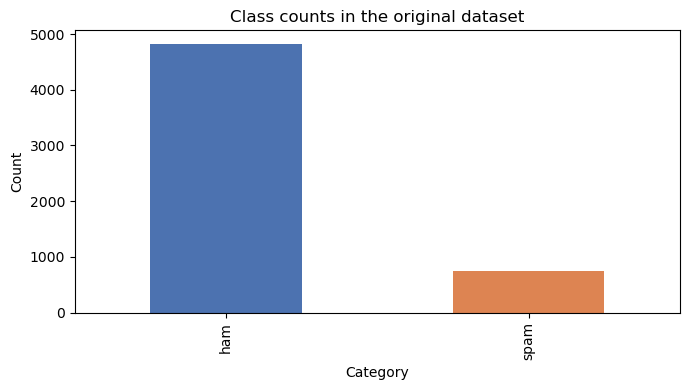

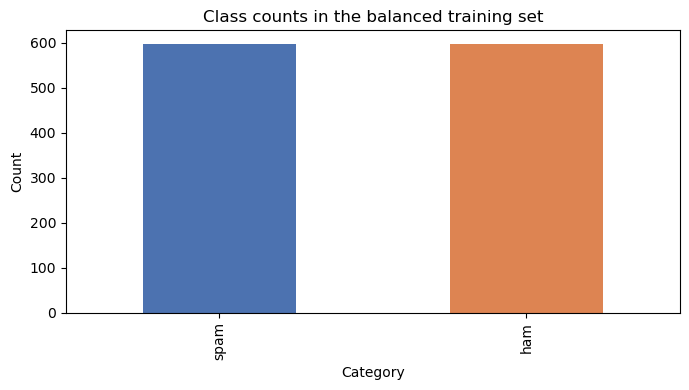

In [6]:
class_counts = pd.DataFrame({
    "original": df["Category"].value_counts(),
    "train": train_df["Category"].value_counts(),
    "balanced_train": balanced_train_df["Category"].value_counts(),
    "test": test_df["Category"].value_counts(),
}).fillna(0).astype(int)

display(class_counts)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
class_counts["original"].plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
ax.set_title("Class counts in the original dataset")
ax.set_xlabel("Category")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
balanced_train_df["Category"].value_counts().plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
ax.set_title("Class counts in the balanced training set")
ax.set_xlabel("Category")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Feature Engineering and Learning Algorithm

Text data must be converted into numeric feature vectors before training a model. We implement a custom vectorizer from scratch that supports both count features and TF-IDF features. The vectorizer is fitted on the training data only, then reused to transform the test data.

The learning algorithm is **Multinomial Naive Bayes from scratch**. This model is appropriate for text classification because it uses word counts or weights to estimate the likelihood of each word in each class. It learns class priors and word likelihoods with Laplace smoothing. The final prediction is the class with the highest log probability.

In [7]:
class ScratchVectorizer:
    def __init__(self, representation="count", min_df=1, max_features=None):
        if representation not in {"count", "tfidf"}:
            raise ValueError("representation must be 'count' or 'tfidf'")
        self.representation = representation
        self.min_df = min_df
        self.max_features = max_features
        self.vocabulary_ = None
        self.feature_names_ = None
        self.idf_ = None
        self.n_docs_ = 0

    @staticmethod
    def tokenize(text):
        text = str(text).lower()
        return re.findall(r"[a-z0-9]+(?:'[a-z0-9]+)?", text)

    def fit(self, texts):
        texts = pd.Series(texts).fillna("")
        self.n_docs_ = len(texts)

        document_frequency = Counter()
        total_frequency = Counter()

        for text in texts:
            tokens = self.tokenize(text)
            total_frequency.update(tokens)
            document_frequency.update(set(tokens))

        eligible_terms = [
            term for term, df_value in document_frequency.items()
            if df_value >= self.min_df
        ]

        ranked_terms = sorted(
            eligible_terms,
            key=lambda term: (-total_frequency[term], term),
        )

        if self.max_features is not None:
            ranked_terms = ranked_terms[: self.max_features]

        self.feature_names_ = ranked_terms
        self.vocabulary_ = {term: idx for idx, term in enumerate(self.feature_names_)}

        if self.representation == "tfidf":
            self.idf_ = np.array([
                np.log((1 + self.n_docs_) / (1 + document_frequency[term])) + 1.0
                for term in self.feature_names_
            ])
        else:
            self.idf_ = None

        return self

    def transform(self, texts):
        if self.vocabulary_ is None:
            raise ValueError("Vectorizer must be fitted before calling transform.")

        texts = pd.Series(texts).fillna("")
        n_docs = len(texts)
        n_features = len(self.feature_names_)
        X = np.zeros((n_docs, n_features), dtype=float)

        for row_idx, text in enumerate(texts):
            tokens = self.tokenize(text)
            if not tokens:
                continue

            counts = Counter(tokens)
            if self.representation == "count":
                for term, count in counts.items():
                    feature_idx = self.vocabulary_.get(term)
                    if feature_idx is not None:
                        X[row_idx, feature_idx] = count
            else:
                total_terms = sum(counts.values())
                for term, count in counts.items():
                    feature_idx = self.vocabulary_.get(term)
                    if feature_idx is not None:
                        tf_value = count / total_terms
                        X[row_idx, feature_idx] = tf_value * self.idf_[feature_idx]

        return X

    def fit_transform(self, texts):
        self.fit(texts)
        return self.transform(texts)

    def get_feature_names_out(self):
        if self.feature_names_ is None:
            raise ValueError("Vectorizer has not been fitted yet.")
        return np.array(self.feature_names_)


class ScratchMultinomialNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.classes_ = None
        self.class_log_prior_ = None
        self.feature_log_prob_ = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        self.classes_, class_counts = np.unique(y, return_counts=True)
        n_features = X.shape[1]
        self.class_log_prior_ = np.log(class_counts / class_counts.sum())
        self.feature_log_prob_ = np.zeros((len(self.classes_), n_features), dtype=float)

        for class_idx, class_label in enumerate(self.classes_):
            X_class = X[y == class_label]
            smoothed_feature_counts = X_class.sum(axis=0) + self.alpha
            smoothed_total = smoothed_feature_counts.sum()
            self.feature_log_prob_[class_idx] = np.log(smoothed_feature_counts / smoothed_total)

        return self

    def predict_log_proba(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.feature_log_prob_.T + self.class_log_prior_

    def predict(self, X):
        log_scores = self.predict_log_proba(X)
        return self.classes_[np.argmax(log_scores, axis=1)]

## Hyperparameter Tuning with Manual Grid Search and 5-Fold Cross-Validation

We perform manual grid search over feature-engineering parameters and Naive Bayes smoothing strength. Each combination is evaluated using 5-fold cross-validation on the balanced training set only. The test set is not used for model selection.

- **representation:** count or tfidf text representation.
- **min_df:** minimum document frequency for a word to be included.
- **max_features:** maximum number of vocabulary features retained.
- **alpha:** Laplace smoothing strength for Multinomial Naive Bayes.

In [8]:
def make_stratified_folds(y, n_splits=5, random_state=42):
    y = np.asarray(y)
    rng = np.random.default_rng(random_state)
    unique_labels = np.unique(y)
    per_label_folds = {label: [] for label in unique_labels}

    for label in unique_labels:
        label_indices = np.where(y == label)[0]
        rng.shuffle(label_indices)
        per_label_folds[label] = np.array_split(label_indices, n_splits)

    folds = []
    all_indices = np.arange(len(y))

    for fold_idx in range(n_splits):
        val_indices = np.concatenate([
            per_label_folds[label][fold_idx] for label in unique_labels
        ])
        train_mask = np.ones(len(y), dtype=bool)
        train_mask[val_indices] = False
        train_indices = all_indices[train_mask]
        folds.append((train_indices, val_indices))

    return folds


param_grid = {
    "representation": ["count", "tfidf"],
    "min_df": [2, 5],
    "max_features": [1000, 2000],
    "alpha": [0.5, 1.0, 2.0],
}

param_combinations = [
    dict(zip(param_grid.keys(), values))
    for values in product(*param_grid.values())
]

folds = make_stratified_folds(balanced_train_df["Category"].to_numpy(), n_splits=5, random_state=SEED)
cv_results = []

for params in param_combinations:
    fold_macro_f1 = []
    fold_accuracy = []
    fold_spam_f1 = []
    fold_ham_f1 = []

    for train_idx, val_idx in folds:
        fold_train = balanced_train_df.iloc[train_idx].reset_index(drop=True)
        fold_val = balanced_train_df.iloc[val_idx].reset_index(drop=True)

        vectorizer = ScratchVectorizer(
            representation=params["representation"],
            min_df=params["min_df"],
            max_features=params["max_features"],
        )

        X_fold_train = vectorizer.fit_transform(fold_train["Message"])
        X_fold_val = vectorizer.transform(fold_val["Message"])

        model = ScratchMultinomialNB(alpha=params["alpha"])
        model.fit(X_fold_train, fold_train["Category"])
        val_pred = model.predict(X_fold_val)

        report = classification_report_manual(
            fold_val["Category"].to_numpy(),
            val_pred,
            labels=["ham", "spam"],
        )

        fold_macro_f1.append(report["macro_f1"])
        fold_accuracy.append(report["accuracy"])
        fold_spam_f1.append(report["f1_spam"])
        fold_ham_f1.append(report["f1_ham"])

    result_row = {
        **params,
        "avg_macro_f1": float(np.mean(fold_macro_f1)),
        "std_macro_f1": float(np.std(fold_macro_f1)),
        "avg_accuracy": float(np.mean(fold_accuracy)),
        "avg_spam_f1": float(np.mean(fold_spam_f1)),
        "avg_ham_f1": float(np.mean(fold_ham_f1)),
    }
    cv_results.append(result_row)

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by=["avg_macro_f1", "std_macro_f1"],
    ascending=[False, True],
).reset_index(drop=True)

best_params = cv_results_df.iloc[0][["representation", "min_df", "max_features", "alpha"]].to_dict()

print("Top CV Results:")
display(cv_results_df.head(10))
print("Best hyperparameters:", best_params)

Top CV Results:


,representation,min_df,max_features,alpha,avg_macro_f1,std_macro_f1,avg_accuracy,avg_spam_f1,avg_ham_f1
0,count,2,2000,2.0,0.955719,0.012419,0.955735,0.955069,0.956370
1,count,2,2000,0.5,0.954866,0.011503,0.954895,0.953848,0.955883
2,tfidf,2,2000,0.5,0.954839,0.008023,0.954867,0.953913,0.955766
3,tfidf,2,2000,2.0,0.954834,0.006021,0.954867,0.953824,0.955845
4,tfidf,2,2000,1.0,0.953996,0.005815,0.954027,0.953101,0.954891
5,count,2,2000,1.0,0.953205,0.013176,0.953228,0.952314,0.954095
6,count,2,1000,2.0,0.952353,0.009604,0.952374,0.951556,0.953150
7,count,5,1000,2.0,0.950691,0.010550,0.950707,0.950013,0.951369
8,count,5,2000,2.0,0.950691,0.010550,0.950707,0.950013,0.951369
9,count,2,1000,1.0,0.950687,0.009866,0.950707,0.949798,0.951575


Best hyperparameters: {'representation': 'count', 'min_df': 2, 'max_features': 2000, 'alpha': 2.0}


## Final Training and Test Evaluation

After selecting the best hyperparameters by average macro F1 in cross-validation, we retrain the final model on the balanced training set. The untouched test set is used only once for the final evaluation. This preserves the integrity of the test split.

In [9]:
final_vectorizer = ScratchVectorizer(
    representation=best_params["representation"],
    min_df=int(best_params["min_df"]),
    max_features=int(best_params["max_features"]),
)

X_train_final = final_vectorizer.fit_transform(balanced_train_df["Message"])
X_test_final = final_vectorizer.transform(test_df["Message"])

final_model = ScratchMultinomialNB(alpha=float(best_params["alpha"]))
final_model.fit(X_train_final, balanced_train_df["Category"])

test_predictions = final_model.predict(X_test_final)
final_report = classification_report_manual(
    test_df["Category"].to_numpy(),
    test_predictions,
    labels=["ham", "spam"],
)

print("Final test set results")
print(f"Main metric: macro F1 = {final_report['macro_f1']:.4f}")
print(f"Accuracy = {final_report['accuracy']:.4f}")
print(f"Spam precision = {final_report['precision_spam']:.4f}")
print(f"Spam recall = {final_report['recall_spam']:.4f}")
print(f"Spam F1 = {final_report['f1_spam']:.4f}")
print(f"Ham precision = {final_report['precision_ham']:.4f}")
print(f"Ham recall = {final_report['recall_ham']:.4f}")
print(f"Ham F1 = {final_report['f1_ham']:.4f}")

print("\nConfusion matrix (rows=true, columns=predicted):")
display(final_report["confusion_matrix"])

prediction_preview = test_df[["Message", "Category"]].copy()
prediction_preview["Prediction"] = test_predictions
prediction_preview["Correct"] = prediction_preview["Category"] == prediction_preview["Prediction"]
display(prediction_preview.head(5))

Final test set results
Main metric: macro F1 = 0.9400
Accuracy = 0.9713
Spam precision = 0.8634
Spam recall = 0.9329
Spam F1 = 0.8968
Ham precision = 0.9895
Ham recall = 0.9772
Ham F1 = 0.9833

Confusion matrix (rows=true, columns=predicted):


,ham,spam
ham,943,22
spam,10,139


,Message,Category,Prediction,Correct
0,If you are not coughing then its nothing,ham,ham,True
1,Beautiful Truth against Gravity.. Read careful...,ham,ham,True
2,We tried to contact you re your reply to our o...,spam,spam,True
3,Will do. Have a good day,ham,ham,True
4,Boo. How's things? I'm back at home and a litt...,ham,ham,True


## Feature Engineering Demonstration on Train and Test Examples

The following examples show how raw SMS messages are converted into numeric features using the fitted vectorizer. This demonstrates the preprocessing and feature extraction applied to both training and test data.

In [10]:
from typing import List


def summarize_features(texts, vectorizer, label_values, source_name, n_examples=3):
    examples = []
    X = vectorizer.transform(texts)
    feature_names = vectorizer.get_feature_names_out()

    for idx in range(min(n_examples, len(texts))):
        original = texts.iloc[idx]
        label = label_values.iloc[idx]
        row_vector = X[idx]
        non_zero_idx = np.where(row_vector > 0)[0]
        sample_features = {
            feature_names[f_idx]: float(row_vector[f_idx])
            for f_idx in non_zero_idx[:10]
        }
        examples.append({
            "source": source_name,
            "original_text": original,
            "true_label": label,
            "active_features": len(non_zero_idx),
            "sample_active_features": sample_features,
        })

    return pd.DataFrame(examples)

print("Feature engineering examples on the train split:")
train_example_df = summarize_features(
    balanced_train_df.loc[balanced_train_df.index[:3], "Message"],
    final_vectorizer,
    balanced_train_df.loc[balanced_train_df.index[:3], "Category"],
    source_name="train",
    n_examples=3,
)
display(train_example_df)

print("Feature engineering examples on the test split:")
test_example_df = summarize_features(
    test_df.loc[test_df.index[:3], "Message"],
    final_vectorizer,
    test_df.loc[test_df.index[:3], "Category"],
    source_name="test",
    n_examples=3,
)
display(test_example_df)

Feature engineering examples on the train split:


,source,original_text,true_label,active_features,sample_active_features
0,train,"44 7732584351, Do you want a New Nokia 3510i c...",spam,24,"{'to': 1.0, 'you': 1.0, 'a': 1.0, 'call': 1.0,..."
1,train,"Ya, told..she was asking wats matter?",ham,6,"{'was': 1.0, 'she': 1.0, 'told': 1.0, 'ya': 1...."
2,train,FreeMsg: Claim ur 250 SMS messages-Text OK to ...,spam,27,"{'to': 1.0, 'for': 1.0, 'now': 1.0, '2': 1.0, ..."


Feature engineering examples on the test split:


,source,original_text,true_label,active_features,sample_active_features
0,test,If you are not coughing then its nothing,ham,7,"{'you': 1.0, 'are': 1.0, 'not': 1.0, 'if': 1.0..."
1,test,Beautiful Truth against Gravity.. Read careful...,ham,13,"{'is': 1.0, 'in': 1.0, 'it': 3.0, 'our': 1.0, ..."
2,test,We tried to contact you re your reply to our o...,spam,25,"{'to': 2.0, 'you': 1.0, 'a': 1.0, 'call': 1.0,..."


Inspect the final model with log-odds ratios to see which words lean most toward spam or ham.

In [11]:
feature_names = final_vectorizer.get_feature_names_out()
class_to_index = {label: idx for idx, label in enumerate(final_model.classes_)}

spam_idx = class_to_index["spam"]
ham_idx = class_to_index["ham"]

log_odds = final_model.feature_log_prob_[spam_idx] - final_model.feature_log_prob_[ham_idx]

spam_words = pd.DataFrame({
    "word": feature_names,
    "log_odds_spam_vs_ham": log_odds,
}).sort_values("log_odds_spam_vs_ham", ascending=False).head(10).reset_index(drop=True)

ham_words = pd.DataFrame({
    "word": feature_names,
    "log_odds_spam_vs_ham": log_odds,
}).sort_values("log_odds_spam_vs_ham", ascending=True).head(10).reset_index(drop=True)

print("Top 10 spam-indicative words:")
display(spam_words)
print("Top 10 ham-indicative words:")
display(ham_words)

Top 10 spam-indicative words:


,word,log_odds_spam_vs_ham
0,claim,3.457507
1,prize,3.293203
2,won,3.052041
3,free,2.911269
4,150p,2.905438
5,uk,2.887738
6,www,2.875762
7,win,2.851371
8,nokia,2.832679
9,txt,2.828898


Top 10 ham-indicative words:


,word,log_odds_spam_vs_ham
0,gt,-3.721611
1,lt,-3.702563
2,lor,-3.118615
3,she,-3.047156
4,he,-2.970195
5,i'll,-2.842361
6,much,-2.795841
7,anything,-2.795841
8,come,-2.713150
9,thk,-2.641691


## Conclusions

In this project, we built a complete from-scratch machine learning flow for SMS spam classification. We loaded the Kaggle SMS spam dataset, created a fixed stratified train/test split because the dataset came as a single CSV, and kept the test set untouched for final evaluation. We handled class imbalance only on the training set by undersampling the training split. Messages were converted into numeric features with a custom text vectorizer, and Multinomial Naive Bayes was implemented from scratch.

The main metric for model selection and evaluation was **macro F1**. The final evaluation also reports spam and ham precision, recall, and F1, along with accuracy and a confusion matrix. Explainability was provided by inspecting the most spam-indicative and ham-indicative words learned by the model.

This notebook is organized to support a clear presentation, with each major step explained and the final evaluation performed only on the untouched test set.